In [1]:
import numpy as np
import matplotlib.pyplot as plt
from typing import Callable, Tuple, List

### Inicjalizacja populacji

In [2]:
def initialization_bats(bounds, n_bats, dims):
    x = np.zeros((n_bats, dims))
    for i in range(n_bats):
        for j in range(dims):
            x[i, j] = bounds[0] + np.random.rand() * (bounds[1] - bounds[0])
    return x

### Aktualizacja pozycji, częstotliwości i prędkości

In [3]:
def update_position_frequency_velocity(xi, vi, best, f_bounds, A_avg, ri):
    f_min, f_max = f_bounds

    beta = np.random.rand()                 # Losowa liczba z zakresu (0,1)
    f = f_min + (f_max - f_min) * beta      # Przypisywanie nowej częstotliwości

    vi = vi + (best - xi) * f                  # Aktualizacja prędkości
    xi += vi                                # Aktualizacja pozycji bata

    if np.random.rand() < ri:
        epsilon = np.random.rand()
        xi = best + epsilon * A_avg         # Lokalna eksploracja

    return xi, vi, f

### Dostosowanie głośności i pulse rate

In [4]:
def adjust_loudness(A, alpha):
    return A * alpha

def adjust_pulse_rate(r0, gamma, t):
    return  r0 * (1 - np.exp(-gamma * t))

## Główna pętal algorytmu

In [5]:
def bat_algorithm(fn,n_bats, bounds, alpha, gamma, f_bounds, max_iter, dims):
    v = np.zeros((n_bats, dims))
    x = initialization_bats(bounds, n_bats, dims)
    f = np.zeros(n_bats)
    A = np.full(n_bats, 1.5)
    r0 = np.full(n_bats, 0.5)

    fitness = np.array([fn(xi) for xi in x])
    best_idx = np.argmin(fitness)
    best = x[best_idx].copy()
    best_f = fitness[best_idx]

    convergence_curve = [best_f]

    history = []
    t = 0
    while t < max_iter:
        a_avg = np.average(A)
        r_new = np.zeros(n_bats)
        for i in range(n_bats):
            r_new[i] = adjust_pulse_rate(r0[i], gamma, t)
            A[i] = adjust_loudness(A[i], alpha)

            x[i], v[i], f[i] = update_position_frequency_velocity(x[i], v[i], best, f_bounds, a_avg, r_new[i])

            x[i] = np.clip(x[i], bounds[0], bounds[1])

            f_new = fn(x[i])

            if np.random.rand() < A[i] and f_new < fitness[i]:
                fitness[i] = f_new
                A[i] = adjust_loudness(A[i], alpha)
                r_new[i] = adjust_pulse_rate(r0[i], gamma, t)


            if f_new < best_f:
                best_f = f_new
                best =x[i].copy()

        history.append(best_f)
        t += 1
        
        convergence_curve.append(best_f)

    return best, best_f, convergence_curve

### Wizualizacja

In [6]:
def plot_convergence(convergence_curve):

    plt.figure(figsize=(10, 6))
    plt.plot(convergence_curve, 'b-', linewidth=2)
    plt.xlabel('Iteracja')
    plt.ylabel('Najlepsza wartość funkcji celu')
    plt.title('Krzywa zbieżności algorytmu Bat')
    plt.grid(True, alpha=0.3)
    plt.yscale('log')
    plt.show()

## Funkcje celu

Sferyczna

In [7]:
def sphere_function(x: np.ndarray) -> float:
    return np.sum(x ** 2)

Funkcja Rastrigina

In [8]:
def rastrigin_function(x: np.ndarray, A: float = 10) -> float:

    n = len(x)
    return A * n + np.sum(x**2 - A * np.cos(2 * np.pi * x))

Funkcja Rosenbrocka

In [9]:
def rosenbrock_function(x: np.ndarray) -> float:

    return np.sum(100.0 * (x[1:] - x[:-1]**2)**2 + (1 - x[:-1])**2)

## Wywołanie

Najlepsze rozwiązanie: [2.66670366e-31 4.38738025e-30 1.26047746e-30 3.16063690e-30
 3.66397656e-30]
Wartość funkcji: 4.432337184518501e-59


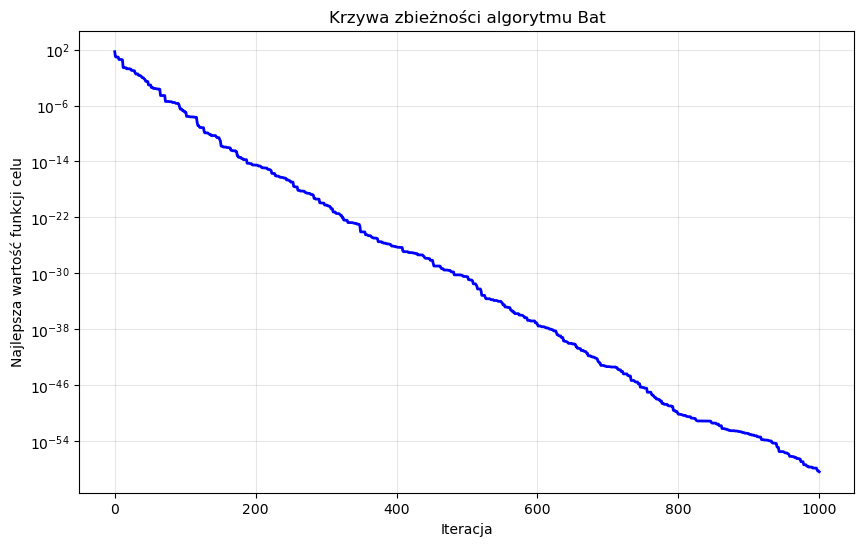

In [10]:
best_solution, best_value, convergence = bat_algorithm(
    fn = sphere_function,
    n_bats = 50,
    bounds = (-10, 10),
    alpha = 0.9,
    gamma = 0.9,
    f_bounds = (0, 2),
    max_iter = 1000,
    dims = 5
)

print("Najlepsze rozwiązanie:", best_solution)
print("Wartość funkcji:", best_value)
plot_convergence(convergence)

## Główna pętla algorytmu z zapisywaniem pozycji agentów

In [11]:
def bat_algorithm_position(fn, n_bats, bounds, alpha, gamma, f_bounds, max_iter, dims,
                  save_every: int = 1):
    """
    Bat Algorithm z logowaniem pozycji (dla dims = 2).
    """

    # Inicjalizacja
    v = np.zeros((n_bats, dims))
    x = initialization_bats(bounds, n_bats, dims)
    f = np.zeros(n_bats)
    A = np.full(n_bats, 1.5)
    r0 = np.full(n_bats, 0.5)

    fitness = np.array([fn(xi) for xi in x])
    best_idx = np.argmin(fitness)
    best = x[best_idx].copy()
    best_f = fitness[best_idx]

    convergence_curve = [best_f]

    # Log pozycji
    positions_log = []
    if dims == 2:
        positions_log.append(x.copy())

    t = 0
    while t < max_iter:

        a_avg = np.average(A)
        r_new = np.zeros(n_bats)

        for i in range(n_bats):

            # Aktualizacja parametrów
            r_new[i] = adjust_pulse_rate(r0[i], gamma, t)
            A[i] = adjust_loudness(A[i], alpha)

            # Aktualizacja pozycji, prędkości i częstotliwości
            x[i], v[i], f[i] = update_position_frequency_velocity(
                x[i], v[i], best, f_bounds, a_avg, r_new[i]
            )

            # Ograniczenia
            x[i] = np.clip(x[i], bounds[0], bounds[1])

            # Nowy fitness
            f_new = fn(x[i])

            # Akceptacja nowego rozwiązania
            if np.random.rand() < A[i] and f_new < fitness[i]:
                fitness[i] = f_new
                A[i] = adjust_loudness(A[i], alpha)
                r_new[i] = adjust_pulse_rate(r0[i], gamma, t)

            # Aktualizacja najlepszego
            if f_new < best_f:
                best_f = f_new
                best = x[i].copy()

        convergence_curve.append(best_f)

        # Logowanie pozycji co save_every iteracji
        if dims == 2 and (t + 1) % save_every == 0:
            positions_log.append(x.copy())

        t += 1

    return best, best_f, convergence_curve, positions_log


### Wywołanie

In [12]:
best_solution, best_value, convergence, position_log = bat_algorithm_position(
    fn = sphere_function,
    n_bats = 20,
    bounds = (-10, 10),
    alpha = 0.9,
    gamma = 0.9,
    f_bounds = (0, 2),
    max_iter = 100,
    dims = 2,
    save_every = 1
)

print("Najlepsze rozwiązanie:", best_solution)
print("Wartość funkcji:", best_value)
print(position_log)

Najlepsze rozwiązanie: [-2.29892046e-05  3.42304666e-05]
Wartość funkcji: 1.7002283728850637e-09
[array([[ 4.40533652,  0.49454695],
       [-9.94344779,  5.64377343],
       [ 1.30381872,  4.29964853],
       [ 1.29033019, -4.732645  ],
       [-4.07289368, -5.77541532],
       [ 4.68713435, -0.50529671],
       [ 6.42200894,  2.24416775],
       [ 8.00694072, -9.16530512],
       [-7.1991631 ,  9.79045785],
       [ 0.52110792, -3.72100257],
       [-7.94709263, -8.97738306],
       [-8.14004371,  9.8367108 ],
       [ 3.7846182 ,  9.62567848],
       [-5.92411638,  2.70280255],
       [ 2.35127837, -0.88056631],
       [-8.13158326, -2.07992687],
       [-2.95416574, -7.32638062],
       [-1.10033909, -5.84922013],
       [ 8.73249927,  7.26432648],
       [ 6.43755335, -5.493247  ]]), array([[ 3.57152028, -0.06366108],
       [ 6.87370141, -3.2804428 ],
       [ 3.13807251, -4.77165909],
       [ 1.56932811, -3.71966251],
       [ 5.70173103,  1.6722856 ],
       [ 1.78937726, -0.9

## Animacja ruchu agentów

In [13]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation

def animate_algorithm(positions_log, bounds, objective_func, interval=200):
    """
    Tworzy animację ruchu agentów algorytmu w 2D.
    
    positions_log: lista [T] elementów, każdy to macierz (n_agentów × 2)
    bounds: [(xmin, xmax), (ymin, ymax)]
    objective_func: funkcja celu f([x, y])
    interval: czas między klatkami w ms
    """

    # Przygotowanie siatki pod contour plot
    x = np.linspace(bounds[0][0], bounds[0][1], 200)
    y = np.linspace(bounds[1][0], bounds[1][1], 200)
    X, Y = np.meshgrid(x, y)
    Z = np.zeros_like(X)

    for i in range(X.shape[0]):
        for j in range(X.shape[1]):
            Z[i, j] = objective_func(np.array([X[i, j], Y[i, j]]))


    fig, ax = plt.subplots(figsize=(7, 7))

    # Tło: poziomice funkcji celu
    ax.contourf(X, Y, Z, levels=50, cmap='viridis')
    ax.set_xlim(bounds[0])
    ax.set_ylim(bounds[1])
    ax.set_title("Ruch agentów algorytmu")

    # Punkty agentów
    scatter = ax.scatter([], [], c='red', s=40)

    # Funkcja aktualizująca klatkę
    def update(frame):
        positions = positions_log[frame]
        scatter.set_offsets(positions)
        ax.set_title(f"Ruch agentów — iteracja {frame}")
        return scatter,

    anim = FuncAnimation(fig, update, frames=len(positions_log), interval=interval, blit=True)

    return anim

In [14]:
%matplotlib inline
from IPython.display import HTML

anim = animate_algorithm(position_log, bounds=[(-10, 10), (-10, 10)], objective_func=sphere_function)
HTML(anim.to_jshtml())